In [1]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-optimize


In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical


In [3]:
df = pd.read_csv('insurance.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [4]:
# change variables from object to categorical 
df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   sex               1338 non-null   int64  
 2   bmi               1338 non-null   float64
 3   children          1338 non-null   int64  
 4   smoker            1338 non-null   int64  
 5   charges           1338 non-null   float64
 6   region_northwest  1338 non-null   bool   
 7   region_southeast  1338 non-null   bool   
 8   region_southwest  1338 non-null   bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 66.8 KB


EXPLORATORY DATA ANALYSIS 

Mean age: 39.20702541106129, Max age: 64, Min age: 18


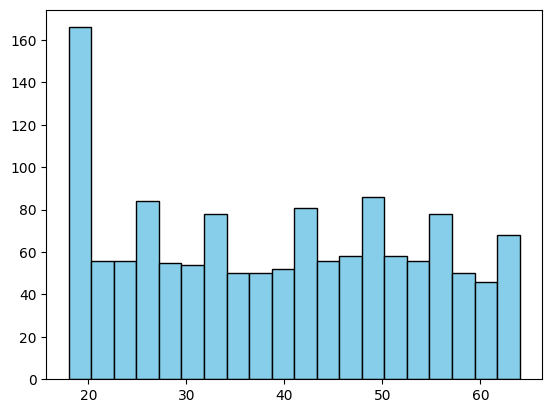

In [6]:
# distribution of age 
plt.hist(df['age'], bins=20, color='skyblue', edgecolor='black')
print(f"Mean age: {df['age'].mean()}, Max age: {df['age'].max()}, Min age: {df['age'].min()}")

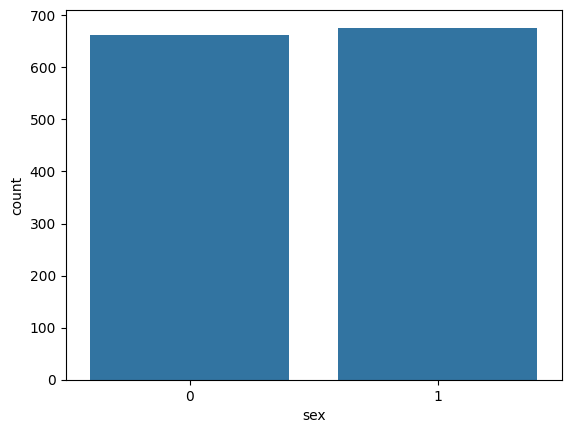

sex
1    676
0    662
Name: count, dtype: int64


In [7]:
# distribution of sex 
sns.countplot(x='sex', data=df)
plt.show()
print(df['sex'].value_counts())

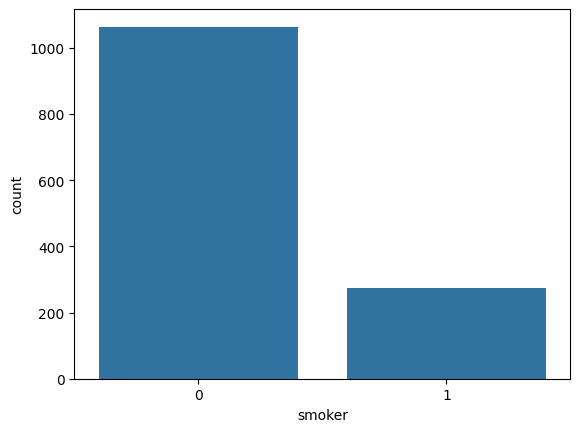

smoker
0    1064
1     274
Name: count, dtype: int64


In [8]:
#distribution of smoker 
sns.countplot(x='smoker', data=df)
plt.show()
print(df['smoker'].value_counts())

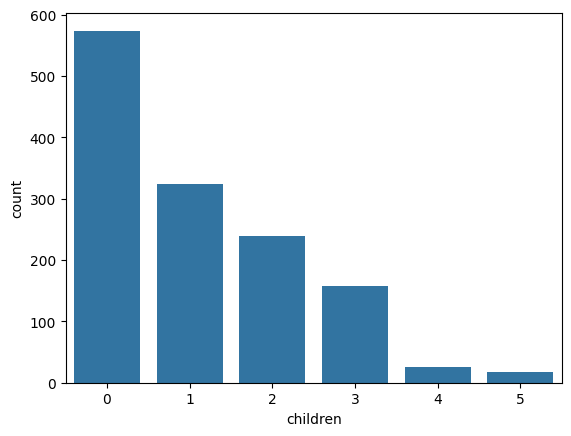

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64


In [9]:
# distribution of children 
sns.countplot(x='children', data=df)
plt.show()
print(df['children'].value_counts())

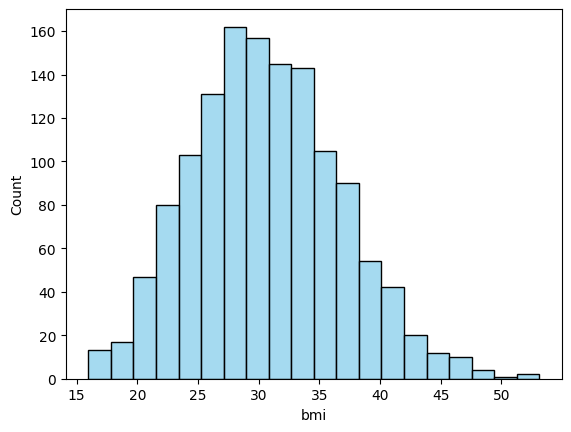

Mean bmi: 30.66339686098655, Max bmi: 53.13, Min bmi: 15.96


In [10]:
# distribution of bmi 
sns.histplot(df['bmi'], bins=20, color='skyblue', edgecolor='black')
plt.show()
print(f"Mean bmi: {df['bmi'].mean()}, Max bmi: {df['bmi'].max()}, Min bmi: {df['bmi'].min()}")

can see bmi as following a normal distribution maybe ???? if that's the case we can use this fact to make future predictions

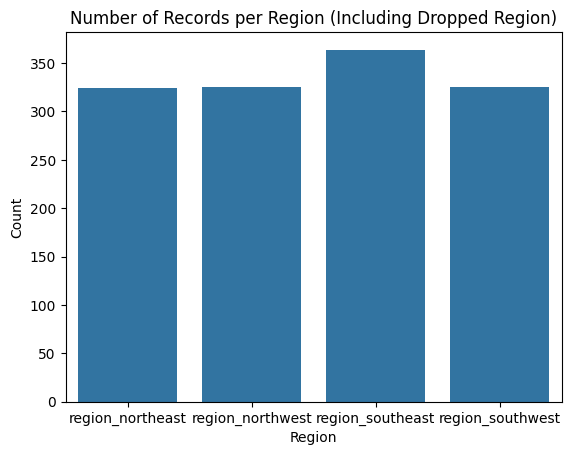

In [11]:
# plot distribution of regions 
# Identify one-hot encoded region columns
region_cols = [col for col in df.columns if col.startswith('region_')]

# Get counts for the encoded regions
region_counts = df[region_cols].sum()

# Compute count for the dropped region
base_region = 'region_northeast'  # <- replace with whichever region was dropped
base_region_count = len(df) - region_counts.sum()

# Add the dropped region to the count series
region_counts[base_region] = base_region_count

# Sort by region name (optional)
region_counts = region_counts.sort_index()

# Plot
sns.barplot(x=region_counts.index, y=region_counts.values)
plt.title('Number of Records per Region (Including Dropped Region)')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

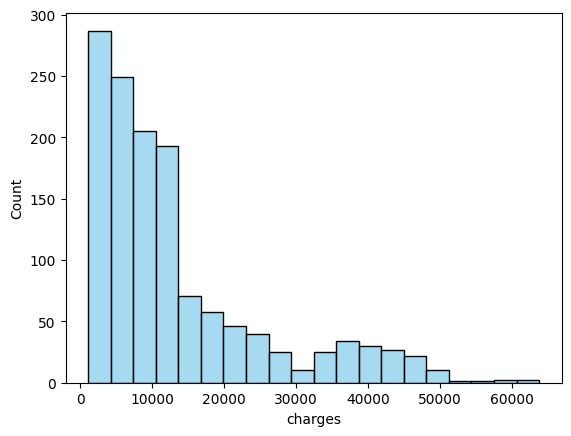

Mean charges: 13270.422265141257, Max charges: 63770.42801, Min charges: 1121.8739


In [12]:
#plot distribution of charges 
sns.histplot(df['charges'], bins=20, color='skyblue', edgecolor='black')
plt.show()
print(f"Mean charges: {df['charges'].mean()}, Max charges: {df['charges'].max()}, Min charges: {df['charges'].min()}")

<Axes: >

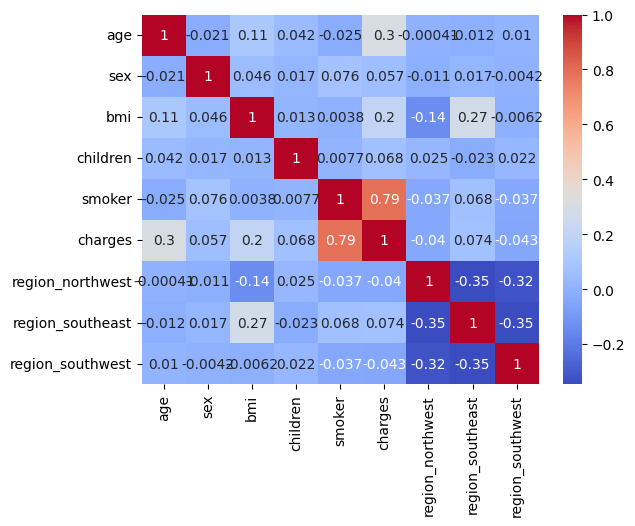

In [13]:
# correlation matrix 
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [14]:
# feature engineering 
df["smokerbmi"] = df["smoker"]*df["bmi"]
df["agechildren"] = df["smoker"]*df["bmi"]
df["agebmi"] = df["smoker"]*df["bmi"]

<Axes: >

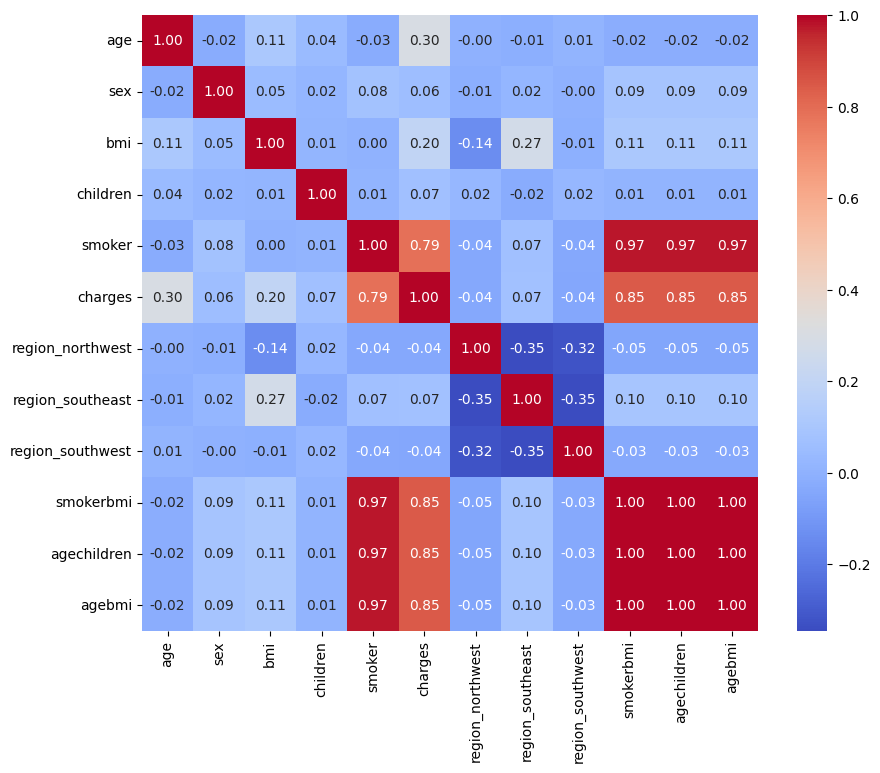

In [15]:
plt.figure(figsize=(10, 8))  # Increase figure size
corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",         # Limit decimals
    cmap="coolwarm",
    annot_kws={"size": 10},  # Annotation font size
    square=True
)


BASELINE MODEL

In [16]:
# train test split 
X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Linear Regression using all features 
X_train_used = X_train.drop(columns=['smokerbmi', 'agechildren', 'agebmi'], errors='ignore')
model = LinearRegression()
model.fit(X_train_used, y_train)

# evaluate the model 
X_test_used = X_test.drop(columns=['smokerbmi', 'agechildren', 'agebmi'], errors='ignore')
y_pred = model.predict(X_test_used)

# plot the results 
print(f"R-squared: {r2_score(y_test, y_pred)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")

# get the coefficients 
coef_df = pd.DataFrame({
    'Feature': X_train_used.columns,
    'Coefficient': model.coef_
})
print(coef_df)

R-squared: 0.7835929767120724
Mean Squared Error: 33596915.85136145
            Feature   Coefficient
0               age    256.975706
1               sex    -18.591692
2               bmi    337.092552
3          children    425.278784
4            smoker  23651.128856
5  region_northwest   -370.677326
6  region_southeast   -657.864297
7  region_southwest   -809.799354


In [18]:
# Linear Regression using only most correlated features, without considering feature engineer 
model1 = LinearRegression()
model1.fit(X_train[["smoker", "bmi", "age"]], y_train)

# evaluate the model 
y_pred1 = model1.predict(X_test[["smoker", "bmi", "age"]])

print(f"R-squared: {r2_score(y_test, y_pred1)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred1)}")

coef_df = pd.DataFrame({
    'Feature': X[["smoker", "bmi", "age"]].columns,
    'Coefficient': model1.coef_
})
print(coef_df)

R-squared: 0.7776932310583375
Mean Squared Error: 34512843.880227886
  Feature   Coefficient
0  smoker  23675.371847
1     bmi    326.450232
2     age    259.410205


In [19]:
# Linear Regression using only smoker 
model2 = LinearRegression()
model2.fit(X_train[["smoker"]], y_train)

# evaluate the model 
y_pred2 = model2.predict(X_test[["smoker"]])

print(f"R-squared: {r2_score(y_test, y_pred2)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred2)}")

print(f"Coefficient for smoker: {model2.coef_[0]}")

R-squared: 0.6602486589056529
Mean Squared Error: 52745964.72752624
Coefficient for smoker: 23188.68587068186


In [20]:
# Linear regression using smoker*bmi and age*children 
model3 = LinearRegression()
model3.fit(X_train[["smokerbmi", "agechildren"]], y_train)

# eval model 
y_pred3 = model3.predict(X_test[["smokerbmi", "agechildren"]])
print(f"R-squared: {r2_score(y_test, y_pred3)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred3)}")

print(f"Coefficients: {model3.coef_}")

R-squared: 0.7514248535514123
Mean Squared Error: 38590976.16652506
Coefficients: [398.37826452 398.37826452]


RANDOM FOREST

📊 Model Performance:
   Metric        Value
R-squared 8.666685e-01
      MSE 2.069954e+07
     RMSE 4.549675e+03
      MAE 2.542954e+03

🌲 Feature Importances:
             Feature  Importance
10            agebmi    0.265163
8          smokerbmi    0.261789
9        agechildren    0.234212
0                age    0.131033
2                bmi    0.061007
3           children    0.021665
1                sex    0.006359
6   region_southeast    0.005778
5   region_northwest    0.005730
7   region_southwest    0.004263
4             smoker    0.003000


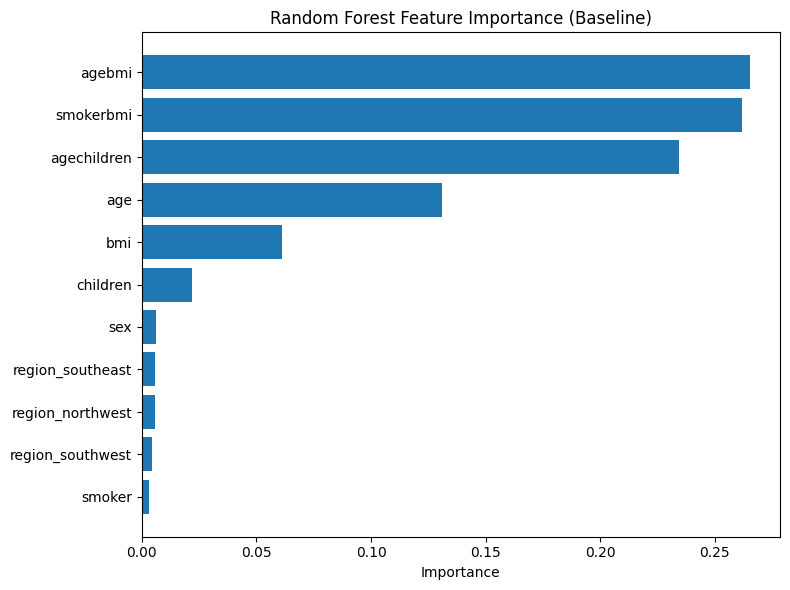

In [21]:
# baseline random forest model (no hyperparameter tuning)
rf1 = RandomForestRegressor()
rf1.fit(X_train, y_train)

y_pred = rf1.predict(X_test)

# --- Performance Metrics ---
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Create a table of results
metrics_df = pd.DataFrame({
    'Metric': ['R-squared', 'MSE', 'RMSE', 'MAE'],
    'Value': [r2, mse, rmse, mae]
})

print("📊 Model Performance:")
print(metrics_df.to_string(index=False))

# --- Feature Importance ---
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf1.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n🌲 Feature Importances:")
print(importances)

# Plot Feature Importance
plt.figure(figsize=(8, 6))
plt.barh(importances['Feature'], importances['Importance'])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance (Baseline)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [22]:
# hyperparameter tuning using GridSearch
# Define the model
rf2 = RandomForestRegressor()

# Define the parameter grid to search
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 2, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Randomized search (more efficient than full grid)
pipeline = GridSearchCV(
    estimator=rf2,
    param_grid=param_dist,
    cv=5,                 
    scoring='neg_mean_squared_error',          
    verbose=2,
    n_jobs=-1
)

# Fit on training data
pipeline.fit(X_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.2s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_

,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [None, 2, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [23]:
print("Best Parameters:", pipeline.best_params_)

# Evaluate on test data
best_rf = pipeline.best_estimator_
y_pred = best_rf.predict(X_test)

print("\nTest Performance:")
print("R²:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Best Parameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Test Performance:
R²: 0.8760344826371071
MSE: 19245489.31931053
RMSE: 4386.968123808348


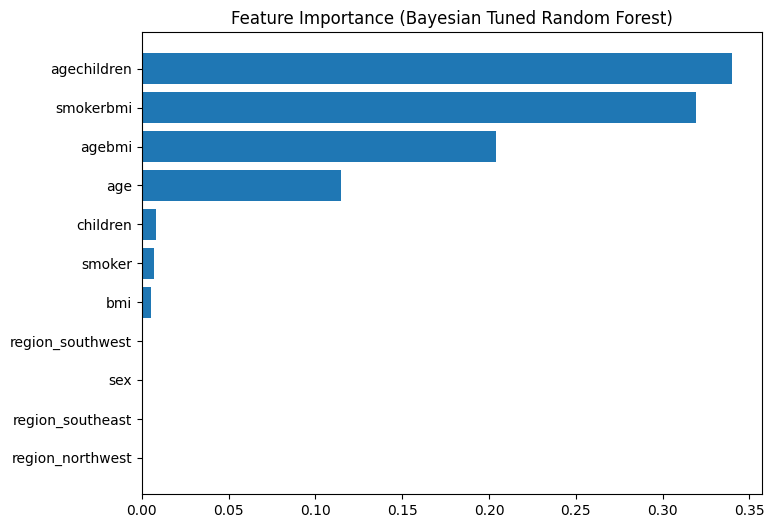

In [ ]:
# plot feature importance 
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(importances['Feature'], importances['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (GridSearch Tuned Random Forest)")
plt.show()

In [25]:
# hyperparameter tuning using BayesianSearch 
rf = RandomForestRegressor()

# Define the hyperparameter search space
search_spaces = {
    'n_estimators': Integer(100, 800),
    'max_depth': Integer(5, 40),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 5),
    'max_features': Categorical([None, 'sqrt', 'log2'])
}

# Set up the Bayesian optimization
opt = BayesSearchCV(
    estimator=rf,
    search_spaces=search_spaces,
    n_iter=30,                
    cv=5,                     
    scoring='neg_mean_squared_error',             
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit to training data
opt.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

,estimator,RandomForestRegressor()
,search_spaces,"{'max_depth': Integer(low=5...m='normalize'), 'max_features': Categorical(c...), prior=None), 'min_samples_leaf': Integer(low=1...m='normalize'), 'min_samples_split': Integer(low=2...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,30
,scoring,'neg_mean_squared_error'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


Best Parameters: OrderedDict([('max_depth', 5), ('max_features', None), ('min_samples_leaf', 3), ('min_samples_split', 7), ('n_estimators', 765)])

Test Performance:
R²: 0.8757
MSE: 19295385.56
RMSE: 4392.65


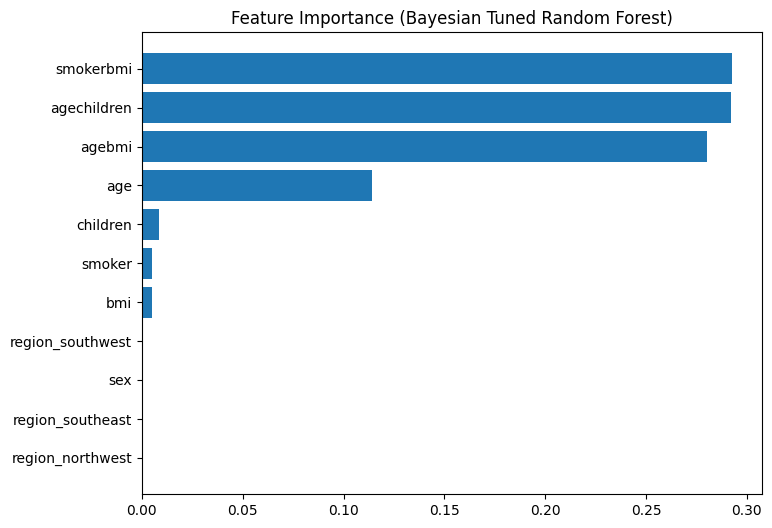

In [26]:
# Print best parameters and results
print("Best Parameters:", opt.best_params_)

# Evaluate on test data
best_rf = opt.best_estimator_
y_pred = best_rf.predict(X_test)

print("\nTest Performance:")
print(f"R²: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# plot feature importance 
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(importances['Feature'], importances['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Bayesian Tuned Random Forest)")
plt.show()
